<a href="https://colab.research.google.com/github/Tejal-singhh/internship-tasks/blob/main/Task4-Sentiment-Analysis/Tejalsingh_Task4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import files
uploaded = files.upload()

Saving Twitter_Data.csv to Twitter_Data.csv


In [2]:
import pandas as pd

df = pd.read_csv("Twitter_Data.csv")
df.shape

(162980, 2)

## Load Dataset

Loaded the Twitter sentiment dataset containing 162,980 tweets, each with a `clean_text` column (the tweet) and a `category` column (sentiment label: -1 = Negative, 0 = Neutral, 1 = Positive).

In [3]:
df = df.dropna()
df = df.sample(n=20000, random_state=42).reset_index(drop=True)
df.shape

(20000, 2)

## Data Preparation

Removed a small number of rows (~11) with missing text or labels, then randomly sampled 20,000 tweets from the full dataset to keep processing and model training fast, while still being large enough for reliable results.

In [4]:
df.columns = ['text', 'label']

label_map = {1.0: 'Positive', 0.0: 'Neutral', -1.0: 'Negative'}
df['label'] = df['label'].map(label_map)

df['label'].value_counts()

,count
label,
Positive,8826
Neutral,6788
Negative,4386


## Class Distribution

Renamed columns to `text` and `label`, and mapped numeric sentiment codes to readable labels (Positive, Neutral, Negative). The sample contains 8,826 Positive, 6,788 Neutral, and 4,386 Negative tweets — a moderate class imbalance, with Positive being the majority class.

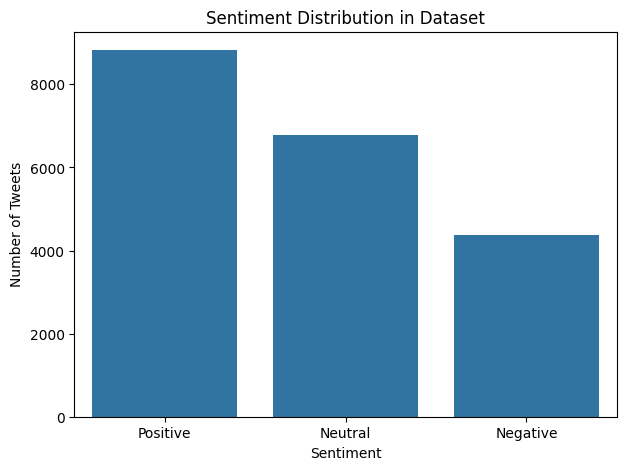

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(7,5))
sns.countplot(data=df, x='label', order=['Positive', 'Neutral', 'Negative'])
plt.title('Sentiment Distribution in Dataset')
plt.xlabel('Sentiment')
plt.ylabel('Number of Tweets')
plt.show()

## Class Distribution

The dataset is moderately imbalanced: Positive tweets (8,826) are the most common, followed by Neutral (6,788), then Negative (4,386). This imbalance means accuracy alone won't tell the full story later — we'll need to check precision/recall per class too, since a model could get decent accuracy just by favoring the majority class.

In [6]:
import nltk
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('punkt')
nltk.download('punkt_tab')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


True

In [7]:
import re
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer

stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def clean_text(text):
    text = str(text).lower()                          # lowercase
    text = re.sub(r'[^a-z\s]', '', text)               # remove punctuation/numbers
    tokens = word_tokenize(text)                       # tokenize into words
    tokens = [word for word in tokens if word not in stop_words]  # remove stopwords
    tokens = [lemmatizer.lemmatize(word) for word in tokens]      # lemmatize
    return ' '.join(tokens)

df['clean_text'] = df['text'].apply(clean_text)
df[['text', 'clean_text']].head()

,text,clean_text
0,news flash modi address the nation cancels tri...,news flash modi address nation cancel trip atm
1,according congress ecosystem bjp divided house...,according congress ecosystem bjp divided house...
2,friends did not have the guts let drdo test mo...,friend gut let drdo test modi please explain p...
3,did modi violate the model code conduct speaki...,modi violate model code conduct speaking armed...
4,raoul gandhy asked modi about nirav for years ...,raoul gandhy asked modi nirav year never asked...


## Text Preprocessing

Built a cleaning pipeline that: converts text to lowercase, removes punctuation/numbers, tokenizes into individual words, removes common stopwords (e.g. "the", "is", "and") that carry no sentiment meaning, and lemmatizes each word to its base form (e.g. "running" → "run"). This reduces noise and vocabulary size before feature extraction, helping the model focus on words that actually signal sentiment.

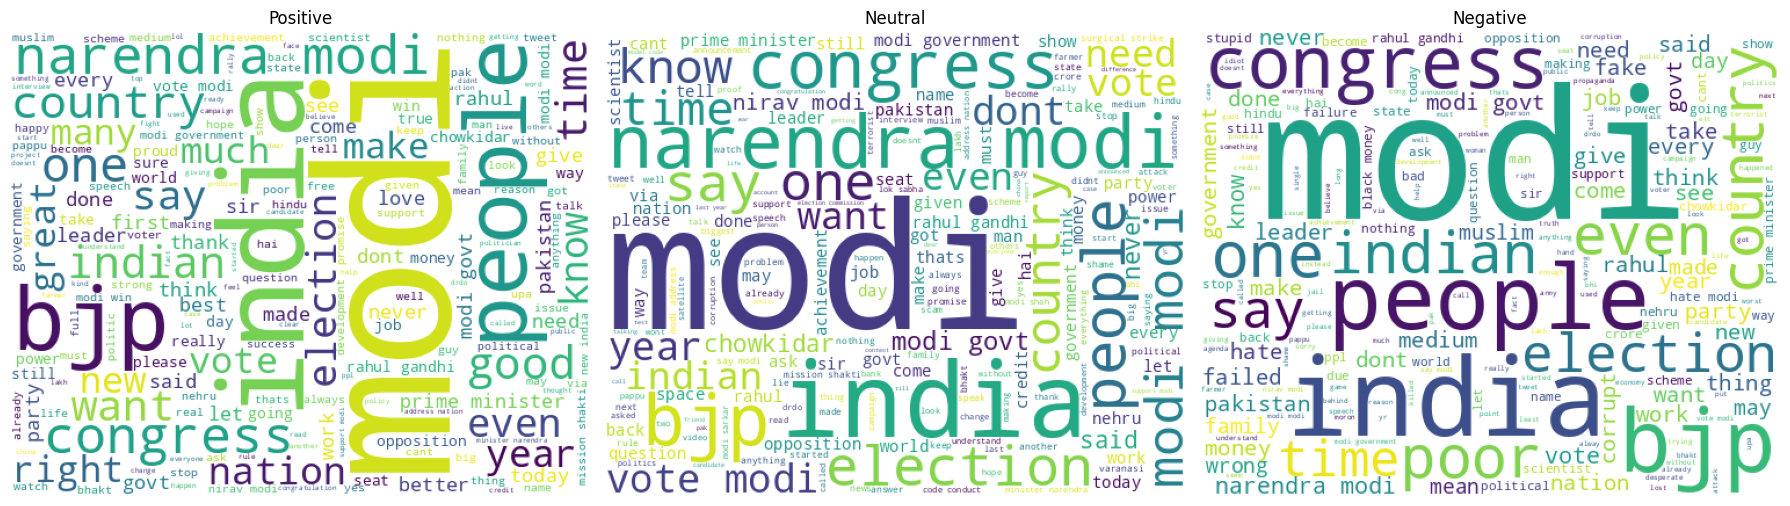

In [8]:
!pip install wordcloud -q
from wordcloud import WordCloud

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for ax, sentiment in zip(axes, ['Positive', 'Neutral', 'Negative']):
    text = ' '.join(df[df['label'] == sentiment]['clean_text'])
    wc = WordCloud(width=500, height=400, background_color='white').generate(text)
    ax.imshow(wc)
    ax.set_title(sentiment)
    ax.axis('off')

plt.tight_layout()
plt.show()

## WordClouds by Sentiment

The WordClouds reveal distinct vocabulary per class: Positive tweets frequently use words like "love," "great," "good," and "support"; Negative tweets are dominated by critical terms like "hate," "bad," "failed," and "corrupt"; Neutral tweets lean toward factual/reporting language ("election," "government," "congress") without strong emotional words. This confirms the text genuinely carries distinguishable sentiment signals, which is a good sign for the classifier we're about to train.

In [9]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(max_features=5000)
X = tfidf.fit_transform(df['clean_text'])
y = df['label']

X.shape

(20000, 5000)

## TF-IDF Feature Extraction

TF-IDF (Term Frequency-Inverse Document Frequency) converts text into numeric vectors by scoring each word based on two things: how often it appears in a specific tweet (Term Frequency) and how rare it is across all tweets (Inverse Document Frequency). Common words that appear in almost every tweet (even after stopword removal) get a lower score, while distinctive words that strongly characterize a specific tweet get a higher score. This turns raw text into a numeric format machine learning models can actually learn from, while automatically down-weighting uninformative, overly common words.

In [10]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Train size:", X_train.shape[0])
print("Test size:", X_test.shape[0])

Train size: 16000
Test size: 4000


In [11]:
from sklearn.naive_bayes import MultinomialNB

nb_model = MultinomialNB()
nb_model.fit(X_train, y_train)

nb_preds = nb_model.predict(X_test)
print("Naive Bayes trained.")

Naive Bayes trained.


In [12]:
from sklearn.linear_model import LogisticRegression

lr_model = LogisticRegression(max_iter=1000)
lr_model.fit(X_train, y_train)

lr_preds = lr_model.predict(X_test)
print("Logistic Regression trained.")

Logistic Regression trained.


## Model Training

Trained two classifiers on the TF-IDF features: **Multinomial Naive Bayes**, a fast probabilistic model that's a common baseline for text classification since it works well with word-frequency data, and **Logistic Regression**, a linear model that often performs strongly on high-dimensional sparse text features like TF-IDF vectors. Both were trained on the same 16,000-tweet training set for a fair comparison.

In [13]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

print("=== Naive Bayes ===")
print("Accuracy:", accuracy_score(y_test, nb_preds))
print(classification_report(y_test, nb_preds))

print("=== Logistic Regression ===")
print("Accuracy:", accuracy_score(y_test, lr_preds))
print(classification_report(y_test, lr_preds))

=== Naive Bayes ===
Accuracy: 0.62975
              precision    recall  f1-score   support

    Negative       0.81      0.27      0.41       918
     Neutral       0.72      0.53      0.61      1358
    Positive       0.57      0.90      0.70      1724

    accuracy                           0.63      4000
   macro avg       0.70      0.57      0.57      4000
weighted avg       0.68      0.63      0.60      4000

=== Logistic Regression ===
Accuracy: 0.7865
              precision    recall  f1-score   support

    Negative       0.81      0.57      0.67       918
     Neutral       0.74      0.87      0.80      1358
    Positive       0.82      0.83      0.82      1724

    accuracy                           0.79      4000
   macro avg       0.79      0.76      0.77      4000
weighted avg       0.79      0.79      0.78      4000



## Model Evaluation

**Logistic Regression significantly outperforms Naive Bayes** (78.65% vs 62.98% accuracy). The gap is most visible in the Negative class: Naive Bayes only catches 27% of actual negative tweets (recall 0.27), frequently misclassifying them as Positive, while Logistic Regression catches 57% and is far more balanced across all three sentiment classes. Logistic Regression's precision, recall, and F1-score are all higher for every class, making it the clearly stronger model for this task.

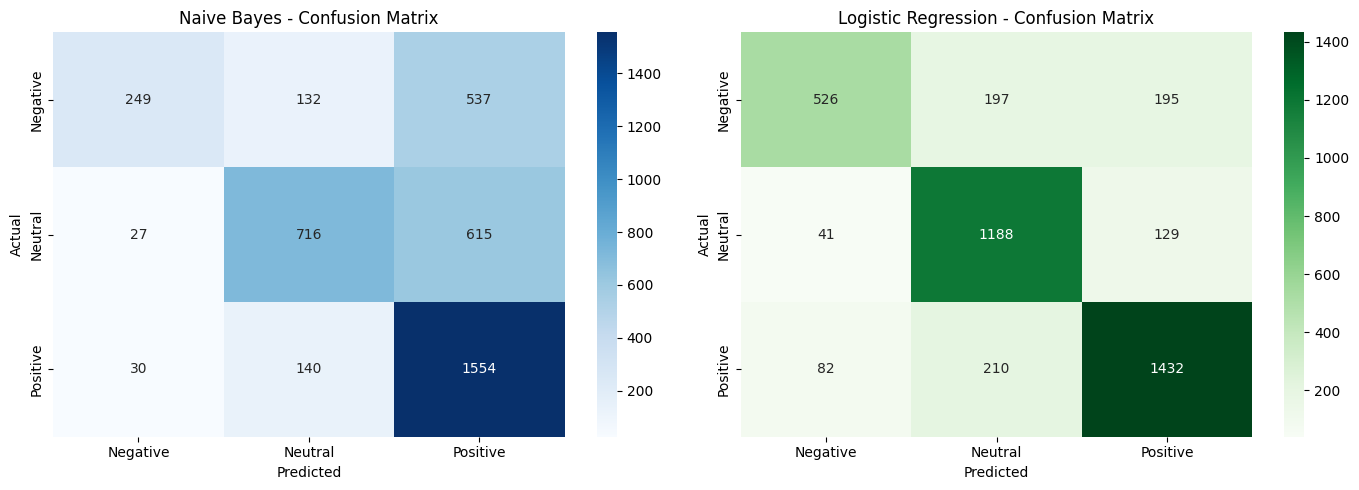

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

cm_nb = confusion_matrix(y_test, nb_preds, labels=['Negative', 'Neutral', 'Positive'])
sns.heatmap(cm_nb, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Negative','Neutral','Positive'],
            yticklabels=['Negative','Neutral','Positive'], ax=axes[0])
axes[0].set_title('Naive Bayes - Confusion Matrix')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')

cm_lr = confusion_matrix(y_test, lr_preds, labels=['Negative', 'Neutral', 'Positive'])
sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Greens',
            xticklabels=['Negative','Neutral','Positive'],
            yticklabels=['Negative','Neutral','Positive'], ax=axes[1])
axes[1].set_title('Logistic Regression - Confusion Matrix')
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('Actual')

plt.tight_layout()
plt.show()

## Confusion Matrix Analysis

The confusion matrices confirm Naive Bayes' main weakness: 537 actual Negative tweets were incorrectly predicted as Positive — a strong bias toward over-predicting the majority class. Logistic Regression shows a much stronger diagonal (correct predictions) across all three classes, with errors spread more evenly rather than concentrated into one systematic bias, confirming it as the better-performing model.

In [15]:
X_test_text = df.loc[y_test.index, 'text']

results = pd.DataFrame({
    'text': X_test_text,
    'actual': y_test,
    'predicted': lr_preds
})

misclassified = results[results['actual'] != results['predicted']]
misclassified.sample(5, random_state=1)

,text,actual,predicted
14431,three most commonly used topics against modi15...,Positive,Neutral
8797,there any possibilities see you modi cabinet 2...,Negative,Positive
17489,then wish you more years modi that you can kee...,Positive,Neutral
14476,are the media guys all modi haters giving him ...,Neutral,Negative
7583,more than 1000 fake muslim are made here troll...,Positive,Negative


## Error Analysis

Examining 5 misclassified examples reveals a common pattern: most errors occur between **adjacent classes** (Positive vs Neutral, Negative vs Positive) rather than completely opposite sentiments — the model rarely confuses a strongly Positive tweet with a strongly Negative one.

Likely reasons for these misclassifications:
1. **Political tweets often mix factual and opinionated language** — a tweet can state a fact about "modi cabinet" while carrying an implicit negative tone that TF-IDF word-frequency alone can't fully capture, since it doesn't understand context, sarcasm, or tone.
2. **Short or ambiguous tweets lack strong sentiment-indicating words** — e.g., a Positive tweet with no obviously "positive" vocabulary can easily get predicted as Neutral, since the model relies on specific trigger words rather than true understanding.
3. **Sarcasm and rhetorical questions** (e.g., tweets phrased as questions or containing implied criticism without explicit negative words) are notoriously hard for word-frequency-based models like TF-IDF + Logistic Regression, since they require understanding intent, not just vocabulary.

This suggests a key limitation: our model recognizes sentiment through word presence, not deeper contextual meaning — a limitation that more advanced approaches (e.g., word embeddings or transformer-based models like BERT) are better equipped to handle.

## Conclusion

**Logistic Regression was the clear winner**, achieving 78.65% accuracy compared to Naive Bayes' 62.98% — a significant 16-point improvement. It was more balanced across all three sentiment classes, particularly on Negative tweets, where Naive Bayes struggled the most (only catching 27% of actual negative tweets vs Logistic Regression's 57%).

**Real-world application:** This kind of sentiment classifier could power **social media monitoring for brands or political campaigns** — automatically tracking public opinion at scale instead of manually reading thousands of tweets. For example, a company could use this to flag a sudden spike in negative sentiment around a product launch or PR incident in near real-time, or a campaign could track how public sentiment shifts after a speech or policy announcement — turning raw social media noise into an actionable, trackable metric.

**Limitations to note:** As the error analysis showed, the model struggles with sarcasm, implicit sentiment, and short ambiguous tweets, since TF-IDF only captures word frequency, not deeper context. For a production system, this could be improved with word embeddings (Word2Vec, GloVe) or a transformer-based model (BERT), which better capture meaning and context rather than just word presence.